# The Girl Born on Tuesday

Some people have strong opinions about this question:

> In a family with two children, if at least one of the children is a girl born on Tuesday, what are the chances that both children are girls?

In this article, I hope to offer

1) A solution to one interpretation of this question,

2) An explanation of *why* the solution seems so counterintuitive,

3) A discussion of other interpretations, and

4) An implication of this problem for teaching and learning probability.

Let's get started.

[Click here to run this notebook on Colab](https://colab.research.google.com/github/AllenDowney/ProbablyOverthinkingIt/blob/book/examples/tuesday.ipynb).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## One interpretation

One reason this problem is contentious is that it is open to multiple interpretations.
I'll start by presenting just one -- then we'll get back to the ambiguity.

First, to avoid real-world complications, let's assume an imaginary world where:

* Every family has two children.

* 50% of children are boys and 50% are girls.

* All days of the week are equally likely birth days.

* Genders and birth days are independent.

Second, we will interpret the question in terms of conditional probability; that is, we'll compute `P(B|A)`, where 

* `A` is "at least one of the children is a girl born on Tuesday", and

* `B` is "both children are girls".

Under these assumptions and this interpretation, the answer is unambiguous -- and it turns out to be `13/27` (about 48.1%).

## But why?

This problem is counterintuitive because it elicits confusion between causation and evidence.

* If a family has a girl born on a Tuesday, that does not *cause* the other child to be a girl.

* But the fact that a family has a girl born on Tuesday is *evidence* that the other child is a girl.

To see why, imagine two families: the first has one girl and the other has **ten** girls.
Suppose I choose one of the families at random, check to see whether they have a girl born on Tuesday, and find that they do.

Which family do you think I chose?

* If I chose the family with one girl, the chance is only `1/7` (about 14%) that she was born on Tuesday.

* If I chose the family with ten girls, the chance is about 79% that at least one of them was born on a Tuesday.

In [2]:
1/7, 1 - (6/7)**10

(0.14285714285714285, 0.7859416843986924)

And that's the key to understanding the problem:

> A family with more than one girl is more likely to have one born on Tuesday.
Therefore, if a family has a girl born on a Tuesday, it is more likely that they have more than one girl.

That's the qualitative argument.
Now we'll make it quantitative -- with Bayes's Theorem.

## Bayes's Theorem

Let's start with four kinds of two-child families.

In [3]:
kinds = ['Boy Boy', 'Boy Girl', 'Girl Boy', 'Girl Girl']

Under our simplifying assumptions, these combinations are equally likely, so their prior probabilities are equal.

In [4]:
def display(series, name):
    return pd.DataFrame({name: series})

In [5]:
from fractions import Fraction

prior = pd.Series(Fraction(1, 4), kinds)
display(prior, 'prior')

,prior
Boy Boy,1/4
Boy Girl,1/4
Girl Boy,1/4
Girl Girl,1/4


Now for each kind of family, let's compute the likelihood of a girl born on Tuesday:

* If there are two boys, the probability of a girl born on Tuesday is `0`.

* If there is one girl, the probability she is born on Tuesday is `1/7`.

* If there are two girls, the probability at least one is born on Tuesday is `1 - (6/7)**2`.

Let's put those values in a list.

In [6]:
p = Fraction(1, 7)
likelihood = [0, p, p, 1 - (1-p)**2]
likelihood

[0, Fraction(1, 7), Fraction(1, 7), Fraction(13, 49)]

To compute the posterior probabilities, we multiply the prior and likelihood, then normalize so the results add up to 1.

In [7]:
posterior = prior * likelihood
posterior /= posterior.sum()
display(posterior, 'posterior')

,posterior
Boy Boy,0
Boy Girl,7/27
Girl Boy,7/27
Girl Girl,13/27


The posterior probability of two girls is `13/27`.
As always, Bayes's Theorem is the chainsaw that cuts through the knottiest problems in probability.

## Other versions

Everything so far is based on the interpretation of the question as a conditional probability.
But many people have pointed out that the question is ambiguous because it does not specify *how we learn* that the family has a girl born on a Tuesday.

This objection is valid: 

1) The answer depends on how we get the information, and 

2) The statement of the problem does not say how.

There are many versions of this problem that specify different ways you might learn that a family has a girl born on a Tuesday, and you might enjoy the challenge of solving them.

In general, if we specify the process that generates the data, we can use simulation, enumeration, or Bayes's Theorem to compute the conditional probability given the data.

But what should we do if the data-generating process is not uniquely specified?

* One option is to say that the question has no answer because it is ambiguous.

* Another option is to specify a prior distribution of possible data-generating processes, compute the answer under each process, and apply the law of total probability.

Some of the people who choose the second option also choose a prior distribution so that the answer turns out to be `1/2`.
In my view, that is a correct answer to one interpretation, but that interpretation seems arbitrary -- by choosing different priors, we can make the answer almost anything.

I prefer the interpretation I presented, because

1) I believe it is what was intended by the people who posed the problem,

2) It is consistent with the conventional interpretation of conditional probability,

3) It yields an answer that seems paradoxical at first, so it is an interesting problem,

4) The apparent paradox can be resolved in a way that sheds light on conditional probability and the idea of independent events.

So I think it's a perfectly good problem -- it's just hard to express it unambiguously in natural language (as opposed to math notation).

But you don't have to agree with me.
If you prefer a different interpretation of the question, and it leads to a different answer, feel free to write a blog post about it.

## What about independence?

I think the girl born on Tuesday carries a lesson about how we teach.
In introductory probability, students often learn two ways to compute the probability of a conjunction.
First they learn the easy way:

* `P(A and B) =  P(A) P(B)`

But they are warned that this only applies if `A` and `B` are *independent*.
Otherwise, they have to do it the hard way:

* `P(A and B) =  P(A) P(B|A)`

But how to we know whether `A` and `B` are independent?
Formally, they are independent if

* `P(B|A) = P(B)`

So, in order to know which formula to use, you have to know `P(B|A)`.
But if you know `P(B|A)`, you might as well use the second formula.

Rather than check independence by conditional probability, it is more common to assert independence by intuition.
For example, if we flip two coins, we have a strong intuition that the outcomes are independent.
And if the coins are known to fair, this intuition is correct.
But if there is any uncertainty about the probability of heads, it is not.

The coin example -- and [Monty Hall](https://allendowney.github.io/ThinkBayes2/chap02.html#the-monty-hall-problem), and [Bertrand's Boxes](https://allendowney.substack.com/p/bertrands-boxes), and many more -- demonstrate the real lesson of the girl born on Tuesday -- **our intuition for independence is wildly unreliable**.

Which means we might want to rethink the way we teach it.

## In general

Previously I wrote about [a version of this problem where the girl is named Florida](https://allendowney.substack.com/p/the-lost-chapter).
In general, if we are given that a family has at least one girl with a particular property, and the prevalence of the property is `p`, we can use Bayes's Theorem to compute the probability of two girls.

I'll use SymPy to represent the priors and the probability `p`.

In [8]:
from sympy import Rational

prior = pd.Series(Rational(1, 4), kinds)
display(prior, 'prior')

,prior
Boy Boy,1/4
Boy Girl,1/4
Girl Boy,1/4
Girl Girl,1/4


Here are the likelihoods in terms of `p`.

In [9]:
from sympy import symbols

p = symbols('p')

likelihood = [0, p, p, 1 - (1-p)**2]
likelihood

[0, p, p, 1 - (1 - p)**2]

And here are the posteriors.

In [10]:
posterior = prior * likelihood
posterior /= posterior.sum()

for kind, prob in posterior.items():
    print(kind, prob.simplify())

Boy Boy 0
Boy Girl -1/(p - 4)
Girl Boy -1/(p - 4)
Girl Girl (p - 2)/(p - 4)


So the general answer is `(p-2) / (p-4)`.

If we plug in `p = 1/7`, we get `13/27` again.

In [11]:
prob = posterior['Girl Girl'].subs({p: Rational(1, 7)})
prob

13/27

Or for the girl named Florida, let's assume one girl out of 1000 is named Florida.

In [12]:
prob = posterior['Girl Girl'].subs({p: Rational(1, 1000)})
prob

1999/3999

The following figure shows the probability of two girls as a function of the prevalence of the property.

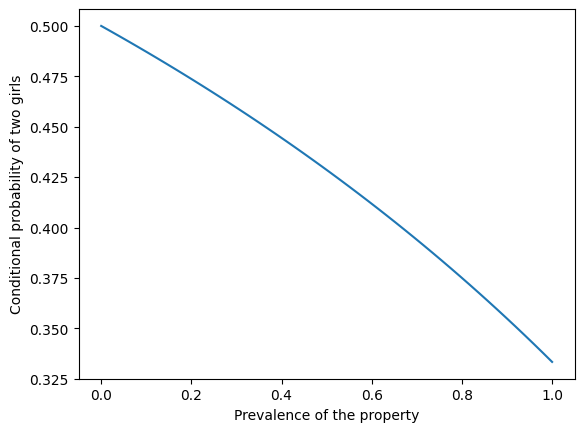

In [13]:
xs = np.linspace(0, 1)
ys = (xs-2) / (xs-4)

plt.plot(xs, ys)
plt.xlabel('Prevalence of the property')
plt.ylabel('Conditional probability of two girls')
None

If the property is rare -- like the name Florida -- the conditional probability is close to `1/2`.
If the property is common -- like having a name -- the conditional probability is close to `1/3`.

## Objections

Here are some objections to the “girl born on Tuesday” problem along with my responses.

### You have to model the message, not just the event

**Objection.**  
The statement “at least one child is a girl born on Tuesday” should not be treated as a bare event in a probability space. It should be treated as the outcome of a random process that generates *messages* or *facts we learn*. Therefore, the probability space must include not only family composition, but also the mechanism by which that information is produced. Any solution that conditions only on the family outcomes is incomplete.

**Response.**  
I agree that if the problem is interpreted as conditioning on a *message* (something that is said, reported, or chosen from among several true statements), then the reporting mechanism matters and must be modeled explicitly. However, I don’t think such a mechanism is required in all cases. It is standard and meaningful to interpret a question as conditioning on an *event* -- an extensional property of outcomes -- without introducing an additional random variable for how the information was obtained. That is the interpretation I adopt here.

### Without a specified selection rule, symmetry forces the answer to 1/2

**Objection.**  
If the problem does not specify how the information was obtained, then we must assume a symmetric rule for selecting which true statement is revealed. Under that assumption, conditioning on “at least one boy” or “at least one girl” must give the same answer, and applying the law of total probability forces the posterior probability to equal the prior. Therefore, the correct answer must be 1/2.

**Response.**  
This conclusion follows only if we assume that the conditioning is on a *message* chosen from a symmetric set of alternatives. Under that interpretation, the result does depend on the selection rule, and `1/2` is a valid answer for one particular choice of rule. But if the conditioning is on an *event* rather than a message, there is no requirement that different events form a symmetric partition or that the law of total probability be applied across them in this way. Under the event-based interpretation, the argument forcing `1/2` does not apply.

### The problem is ambiguous and therefore has no answer

**Objection.**  
Because the problem does not specify how we learn that there is a girl born on Tuesday, it is fundamentally ambiguous. Since different interpretations lead to different answers, the question has no single correct solution.

**Response.**  
It’s true that the problem is ambiguous as stated in natural language. One option is to declare it unanswerable. Another is to resolve the ambiguity by adopting a conventional default interpretation. I choose the latter: I interpret the question as a conditional probability defined on an explicit probability model and make that interpretation clear by enumerating the sample space. Under that interpretation, the answer is unambiguous and, in my view, interesting and instructive -- even if other interpretations lead to different answers.

### You are changing the sampling procedure

**Objection.**  
Some people object that the `13/27` result comes from changing how families are selected. Conditioning on “at least one child is a girl born on Tuesday” oversamples families with more girls, so the conditional distribution no longer represents the original population of two-child families. From this perspective, the result feels like an artifact of biased sampling rather than a genuine probability update.

**Response.**  
That description is accurate, but it is not a flaw. Conditioning *is* biased sampling: evidence changes the distribution of outcomes. Families with more girls really are more likely to satisfy the condition, and the conditional probability reflects that fact.

### The day of the week seems irrelevant

**Objection.**  
Tuesday has nothing to do with gender, so it feels wrong that adding this detail should change the probability. Since the day of the week does not *cause* a child to be a girl, it seems irrelevant to the question.

**Response.**  
This objection reflects a common confusion between causal independence and evidential relevance. While the day of the week does not cause the other child’s gender, it provides evidence about the number of girls in the family. Evidence can change probabilities even when there is no causal connection.

### The result depends on unrealistic independence assumptions

**Objection.**  
The solution assumes that genders and days of the week are independent and uniformly distributed, which is not true in the real world. If those assumptions are relaxed, the answer changes.

**Response.**  
That is correct, but those assumptions are not the source of the puzzle. Relaxing them changes the numerical value of the answer, but not the underlying logic. The same kind of reasoning applies under more realistic models.

### The problem is artificial or pathological

**Objection.**  
Some readers reject the problem not because the calculation is wrong, but because the setup feels artificial or unlike how information is learned in real life. From this view, the problem is a trick rather than a meaningful probability question.

**Response.**  
Whether this is a flaw or a feature depends on the goal. The problem is artificial, but it is intended to expose how unreliable our intuitions about conditional probability and independence can be. In that sense, its artificiality is what makes it pedagogically useful.
The underlying issue -- determining how evidence bears on hypotheses -- comes up in real-world problems all the time.
And getting it wrong has real-world consequences.

Copyright 2025 Allen B. Downey

License: [Attribution-NonCommercial-ShareAlike 4.0 International (CC BY-NC-SA 4.0)](https://creativecommons.org/licenses/by-nc-sa/4.0/)